In [51]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from matplotlib.ticker import MaxNLocator
import matplotlib.patches as mpatches
from scipy import stats

from dae_finder import PolyFeatureMatrix
import Comparison
from Recover_Model import Recover_Model_sindy
import importlib
from Basis import OrthogonalLibrary, Monomials, standardize_columns, normalization
from Sample_Analysis import create_initial_conditions, sampling, distribution_test
from Base_test import CRN, Lotka_Volterra

import matplotlib as mpl


Plots for Part 1: Ill-posedness is Prevalent in the Recovery of Systems Biology Models

In [52]:
# Output paths and font size
out_path_plots1 = Path("/Users/yuxiangfeng/Desktop/SINDy/Plots/Fig1_final")
font_size = 15
mpl.rcParams["svg.fonttype"] = "none"

CRN: Sampling rates: from 0 to 51, every 3 hr a point

In [4]:
# Chemical Reaction Network
dir_crn = Path("/Users/yuxiangfeng/Desktop/SINDy/Base_test/CRN")
CRN_model = pd.read_excel(dir_crn / 'Model_CRN.xlsx')
k_rates = {"k":2.12456, "kr":1.10124, "kcat":1.5093}
init_cond = [2.5,2,1,0]
final_time = 10
#time_span_original = np.array([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 28, 32, 36, 40, 44, 48, 51])
time_span_original = np.array([0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 47, 51])
ratio = final_time/51
solvedT = ratio * time_span_original
noise_level = 0.3
CRN = CRN(k_rates,init_cond,solvedT,noise_level=None)

data_overall_crn = CRN.data_sim
#data_overall.rename(columns={"S":"x1", "E":"x2", "ES":"x3","P":"x4", 
                             #"dSdt":"dx1dt", "dEdt":"dx2dt", "dESdt":"dx3dt", "dPdt":"dx4dt"},inplace=True)
data_overall_crn.rename(columns={"S":"x1", "E":"x2", "ES":"x3","P":"x4"},inplace=True)
data_crn = data_overall_crn[['time','x1','x2','x3','x4']]
#data_dot_crn = data_overall_crn[['dx1dt','dx2dt',"dx3dt","dx4dt"]]
data_states_crn = data_overall_crn[['x1','x2','x3','x4']]

min_crn = data_states_crn.min()
max_crn = data_states_crn.max()

In [5]:
# normalize for orthogonal basis
time_column = data_crn['time']
data_states_crn_normalized = normalization(data_states_crn)[0]
data_crn_normalized = pd.concat([time_column, data_states_crn_normalized], axis=1)

Lotka-Volterra: 1900-1920, a point per year

In [6]:
# 1 prey, 2 predators Lotka-Volterra model
dir_lv = Path("/Users/yuxiangfeng/Desktop/SINDy/Base_test/Lotka-Volterra")
LV_model = pd.read_excel(dir_lv / 'Model_LV_1_2.xlsx')
params = {"r":0.2, "K":1.7, "a1":0.1, "a2":0.2, "m1":0.1, "m2":0.1, "epsilon1":1.0, "epsilon2":2.0}
t_span = (0,20)
t_eval = np.linspace(t_span[0],t_span[1],21)

#z0 = [10,10]
z0 = [1.7,1.0,1.7]
noise_level = 0.1
LV = Lotka_Volterra(params,t_span,t_eval,z0,noise_level=None)

data_overall_lv = LV.data_sim
data_overall_lv.rename(columns={"x":"x1", "y1":"x2", "y2":"x3", "dxdt":"dx1dt", "dy1dt":"dx2dt", "dy2dt":"dx3dt"},inplace=True)
data_lv = data_overall_lv[['time','x1','x2','x3']]
#data_dot_lv = data_overall_lv[['dx1dt','dx2dt','dx3dt']]
data_states_lv = data_overall_lv[['x1','x2','x3']]

min_lv = data_states_lv.min()
max_lv = data_states_lv.max()

In [7]:
# normalize for orthogonal basis
time_column = data_lv['time']
data_states_lv_normalized = normalization(data_states_lv)[0]
data_lv_normalized = pd.concat([time_column, data_states_lv_normalized], axis=1)

Plots 0: Simulation for both systems

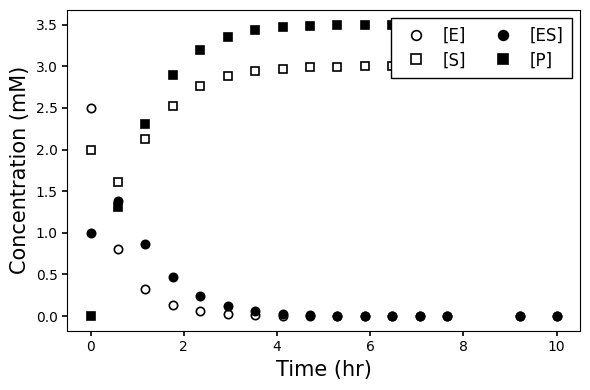

In [117]:
from matplotlib.lines import Line2D

# all-black styling: shape + filled/unfilled
style_map = {
    "x1": dict(marker="o", face="none", edge="black"),  # open triangle
    "x2": dict(marker="s", face="none", edge="black"),  # open square
    "x3": dict(marker="o", face="black", edge="black"), # open circle
    "x4": dict(marker="s", face="black", edge="black"), # filled square
}

label_map = {
    'x1': '[E]',
    'x2': '[S]',
    'x3': '[ES]',
    'x4': '[P]',
}

fig, ax = plt.subplots(figsize=(6, 4))

t = data_overall_crn['time']

for col in ['x1', 'x2', 'x3', 'x4']:
    st = style_map[col]
    ax.plot(
        t, data_overall_crn[col],
        linestyle='None',
        marker=st["marker"],
        markersize=6,
        markerfacecolor=st["face"],       # 'none' -> open marker
        markeredgecolor=st["edge"],
        markeredgewidth=1.2,              # make outlines crisp
        alpha=1.0
    )

# axis styling
ax.set_xlabel('Time (hr)', fontsize=font_size)
ax.set_ylabel('Concentration (mM)', fontsize=font_size)
ax.tick_params(axis='both', which='major', length=3.5, width=1.2)

# legend
legend_handles = [
    Line2D([0], [0],
           linestyle='None',
           marker=style_map[col]["marker"],
           markersize=7,
           markerfacecolor=style_map[col]["face"],
           markeredgecolor='black',
           markeredgewidth=1.2,
           label=label_map[col])
    for col in ['x1', 'x2', 'x3', 'x4']
]

ax.legend(
    handles=legend_handles,
    frameon=True, fancybox=False,
    framealpha=1.0,
    borderpad=0.5, labelspacing=0.4,
    handletextpad=0.6, columnspacing=1.2,
    edgecolor='black',
    loc='upper right', ncol=2, fontsize=12
)

plt.tight_layout()
plt.savefig(out_path_plots1 / "scatter_CRN.svg",
            format="svg", bbox_inches="tight", pad_inches=0.02)
plt.show()

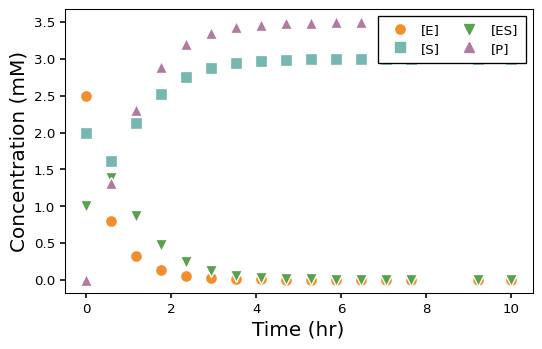

In [77]:
# Colors & markers matching the paper
#color_map = {
#   'x1': '#f28e2b',  
#    'x2': '#4e79a7',  
#    'x3': '#b07aa1',  
#    'x4': '#59a14f',  
# }

color_map = {
    "x1": "#F28E2B",
    "x2":  "#76B7B2",
    "x3":  "#59A14F",
    "x4": "#B07AA1",
    #"gray":   "#9D9D9D",   
}

marker_map = {
    'x1': 'o',
    'x2': 's',
    'x3': 'v',
    'x4': '^',
}

label_map = {
    'x1': '[E]',
    'x2': '[S]',
    'x3': '[ES]',
    'x4': '[P]',
}

fig, ax = plt.subplots(figsize=(5.7480, 3.7402),dpi=96)

for col in ['x1', 'x2', 'x3', 'x4']:
    t = data_overall_crn['time']
    val = data_overall_crn[col]

    # ax.plot(
    #     t, val,
    #     color=color_map[col],
    #     linewidth=2.5,
    # )
    
    # Only keep scatter points
    ax.plot(
        t, val,
        linestyle='None',  
        marker=marker_map[col],
        markersize=9,
        markerfacecolor=color_map[col],
        markeredgecolor="white",
        alpha=1.0,  
    )

# axis styling
ax.set_xlabel('Time (hr)', fontsize=font_size)
ax.set_ylabel('Concentration (mM)', fontsize=font_size)

ax.tick_params(axis='both', which='major', length=3.5, width=1.2)

legend_handles = [
    Line2D([0], [0],
           linestyle='None',  
           color=color_map[col],
           marker=marker_map[col],
           markersize=7,
           markerfacecolor=color_map[col],
           markeredgecolor=color_map[col],
           label=label_map[col])
    for col in ['x1', 'x2', 'x3', 'x4']
]

ax.legend(handles=legend_handles, 
          frameon=True, fancybox=False, 
          framealpha=1.0,borderpad=0.6, labelspacing=0.4,
          handletextpad=0.6,columnspacing=1.2,
          edgecolor='black',
          loc='upper right', ncol=2, fontsize=10)

plt.tight_layout()
plt.savefig(out_path_plots1 / "scatter_CRN.svg", format="svg", bbox_inches="tight",
            pad_inches=0.02)
#plt.savefig(out_path_plots1 / "scatter_CRN.png", dpi=300,
#            bbox_inches="tight", pad_inches=0.02)
plt.show()

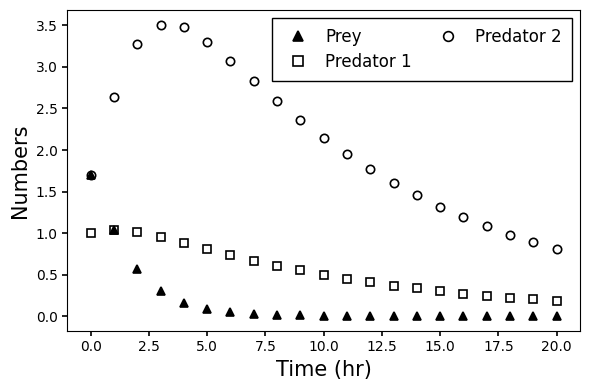

In [118]:
# all-black styling: shape + filled/unfilled
style_map = {
    "x1": dict(marker="^", face="black", edge="black"),  # filled circle
    "x2": dict(marker="s", face="none", edge="black"),  # open square
    "x3": dict(marker="o", face="none", edge="black"),  # open circle
}

label_map = {
    'x1': 'Prey',
    'x2': 'Predator 1',
    'x3': 'Predator 2',
}

fig, ax = plt.subplots(figsize=(6,4))

for col in ['x1', 'x2', 'x3']:
    st = style_map[col]
    t = data_lv['time']
    val = data_lv[col]
    ax.plot(
        t, val,
        linestyle='None',
        marker=st["marker"],
        markersize=6,
        markerfacecolor=st["face"],       # 'none' -> open marker
        markeredgecolor=st["edge"],
        markeredgewidth=1.2,              # make outlines crisp
        alpha=1.0
    )
    #ax.scatter(  
    #    t, val,
    #    marker=marker_map[col],
    #    s=50,  
    #    facecolor=color_map[col],
    #    edgecolor=color_map[col],
    #    alpha=1.0, 
    #)

# axis styling
ax.set_xlabel('Time (hr)', fontsize=font_size)
ax.set_ylabel('Numbers', fontsize=font_size)

ax.tick_params(axis='both', which='major', length=3.5, width=1.2)

#legend
legend_handles = [
    Line2D([0], [0],
           linestyle='None',
           marker=style_map[col]["marker"],
           markersize=7,
           markerfacecolor=style_map[col]["face"],
           markeredgecolor='black',
           markeredgewidth=1.2,
           label=label_map[col])
    for col in ['x1', 'x2', 'x3']
]

ax.legend(
    handles=legend_handles,
    frameon=True, fancybox=False,
    framealpha=1.0,borderpad=0.6, labelspacing=0.4,
    handletextpad=0.6,columnspacing=1.2,
    edgecolor='black',
    loc='upper right',
    ncol=2,         
    fontsize=12
)

plt.tight_layout()
plt.savefig(out_path_plots1 / "scatter_LV.svg", format="svg", bbox_inches="tight",
            pad_inches=0.02)
#plt.savefig(out_path_plots1 / "scatter_LV.png", dpi=96,
            #bbox_inches="tight", pad_inches=0.02)
plt.show()

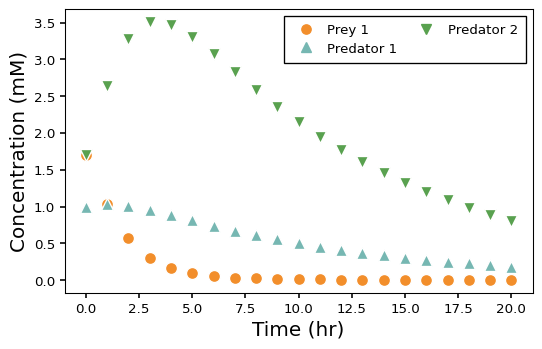

In [ ]:
# Colors & markers matching the paper
#color_map = {
#    'x1': '#f28e2b', 
#    'x2': '#4e79a7',  
#    'x3': '#b07aa1',  
#}

color_map = {
    "x1": "#F28E2B",
    "x2":  "#76B7B2",
    "x3":  "#59A14F",
    #"x4": "#B07AA1",
    #"gray":   "#9D9D9D",   
}

marker_map = {
    'x1': 'o',
    'x2': '^',
    'x3': 'v',
}

label_map = {
    'x1': 'Prey 1',
    'x2': 'Predator 1',
    'x3': 'Predator 2',
}

fig, ax = plt.subplots(figsize=(5.7480, 3.7402),dpi=96)

for col in ['x1', 'x2', 'x3']:
    t = data_lv['time']
    val = data_lv[col]
    ax.plot(
        t, val,
        linestyle='None',  
        marker=marker_map[col],
        markersize=9,
        markerfacecolor=color_map[col],
        markeredgecolor="white",
        alpha=1.0,  
    )
    #ax.scatter(  
    #    t, val,
    #    marker=marker_map[col],
    #    s=50,  
    #    facecolor=color_map[col],
    #    edgecolor=color_map[col],
    #    alpha=1.0, 
    #)

# axis styling
ax.set_xlabel('Time (hr)', fontsize=font_size)
ax.set_ylabel('Numbers', fontsize=font_size)

ax.tick_params(axis='both', which='major', length=3.5, width=1.2)

legend_handles = [
    Line2D([0], [0],
           linestyle='None',
           color=color_map[col],
           marker=marker_map[col],
           markersize=7,
           markerfacecolor=color_map[col],
           markeredgecolor=color_map[col],
           label=label_map[col])
    for col in ['x1', 'x2', 'x3']
]

ax.legend(
    handles=legend_handles,
    frameon=True, fancybox=False,
    framealpha=1.0,borderpad=0.6, labelspacing=0.4,
    handletextpad=0.6,columnspacing=1.2,
    edgecolor='black',
    loc='upper right',
    ncol=2,         
    fontsize=10
)

plt.tight_layout()
plt.savefig(out_path_plots1 / "scatter_LV.svg", format="svg", bbox_inches="tight",
            pad_inches=0.02)
#plt.savefig(out_path_plots1 / "scatter_LV.png", dpi=96,
            #bbox_inches="tight", pad_inches=0.02)
plt.show()

Plots 1: The number of ill-posed combinations of baseline models, and the plot has four subplots. Each of them has four lines representing basis (Monomial, Legendre, Chebyshev and Laguerre), x axis representing degree, y axis representing log10 number

In [47]:
degree_list = [1,2,3,4,5]
comb_list = [2,3]
summary_monomial_crn = Comparison.run_noise_free_analysis(data_crn ,degree_list, comb_list,'Monomial')
summary_legendre_crn = Comparison.run_noise_free_analysis(data_crn_normalized ,degree_list, comb_list,'Legendre')
summary_chebyshev_crn = Comparison.run_noise_free_analysis(data_crn_normalized ,degree_list, comb_list,'Chebyshev')
summary_laguerre_crn = Comparison.run_noise_free_analysis(data_crn ,degree_list, comb_list,'Laguerre')

>>> Running noise-free analysis...
>>> Generating candidate libraries...
    Degrees: [1, 2, 3, 4, 5]
    Combinations: [2, 3]
>>> Running noise-free analysis...
>>> Generating candidate libraries...
    Degrees: [1, 2, 3, 4, 5]
    Combinations: [2, 3]
>>> Running noise-free analysis...
>>> Generating candidate libraries...
    Degrees: [1, 2, 3, 4, 5]
    Combinations: [2, 3]
>>> Running noise-free analysis...
>>> Generating candidate libraries...
    Degrees: [1, 2, 3, 4, 5]
    Combinations: [2, 3]


In [48]:
degree_list = [1,2,3,4,5]
comb_list = [2,3]
summary_monomial_lv = Comparison.run_noise_free_analysis(data_lv ,degree_list, comb_list,'Monomial')
summary_legendre_lv = Comparison.run_noise_free_analysis(data_lv_normalized ,degree_list, comb_list,'Legendre')
summary_chebyshev_lv = Comparison.run_noise_free_analysis(data_lv_normalized ,degree_list, comb_list,'Chebyshev')
summary_laguerre_lv = Comparison.run_noise_free_analysis(data_lv ,degree_list, comb_list,'Laguerre')

>>> Running noise-free analysis...
>>> Generating candidate libraries...
    Degrees: [1, 2, 3, 4, 5]
    Combinations: [2, 3]
>>> Running noise-free analysis...
>>> Generating candidate libraries...
    Degrees: [1, 2, 3, 4, 5]
    Combinations: [2, 3]
>>> Running noise-free analysis...
>>> Generating candidate libraries...
    Degrees: [1, 2, 3, 4, 5]
    Combinations: [2, 3]
>>> Running noise-free analysis...
>>> Generating candidate libraries...
    Degrees: [1, 2, 3, 4, 5]
    Combinations: [2, 3]


In [49]:
summary_monomial_crn

,degree,# lib terms,# ill-posed 2comb,# ill-posed 3comb
0,1,4,1,4
1,2,14,11,147
2,3,34,38,1469
3,4,69,101,8823
4,5,125,235,39154


In [50]:
# ===== Build dfs_lv / dfs_crn for plotting =====

COL_DEG = "degree"
COL_2C  = "# ill-posed 2comb"
COL_3C  = "# ill-posed 3comb"

def _standardize_summary_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    Normalize column names so the plotting code can always find:
      - degree
      - # ill-posed 2comb
      - # ill-posed 3comb
    """
    if df is None:
        return None

    out = df.copy()

    # compact whitespace in col names
    norm = {c: " ".join(str(c).strip().split()) for c in out.columns}
    rename_map = {}

    # degree
    for c, cn in norm.items():
        if cn.lower() in ["deg", "degree"]:
            rename_map[c] = COL_DEG

    # ill-posed 2comb / 3comb (robust to '-', '_', spaces)
    for c, cn in norm.items():
        cn_low = cn.lower().replace("_", " ").replace("-", " ")
        if ("ill" in cn_low and "posed" in cn_low and "comb" in cn_low):
            if "2" in cn_low:
                rename_map[c] = COL_2C
            if "3" in cn_low:
                rename_map[c] = COL_3C

    out = out.rename(columns=rename_map)

    # ensure degree is integer for clean x-axis ticks
    if COL_DEG in out.columns:
        out[COL_DEG] = out[COL_DEG].astype(int)

    return out

# --- LV ---
dfs_lv = {
    "Monomial":  _standardize_summary_df(summary_monomial_lv),
    "Legendre":  _standardize_summary_df(summary_legendre_lv),
    "Chebyshev": _standardize_summary_df(summary_chebyshev_lv),
    "Laguerre":  _standardize_summary_df(summary_laguerre_lv),
}

# --- CRN ---
dfs_crn = {
    "Monomial":  _standardize_summary_df(summary_monomial_crn),
    "Legendre":  _standardize_summary_df(summary_legendre_crn),
    "Chebyshev": _standardize_summary_df(summary_chebyshev_crn),
    "Laguerre":  _standardize_summary_df(summary_laguerre_crn),
}

/var/folders/rl/rxtrqh0d3zz5hjzkb_g0_d3m0000gn/T/ipykernel_58387/1564124273.py:3: RuntimeWarning:

divide by zero encountered in log10



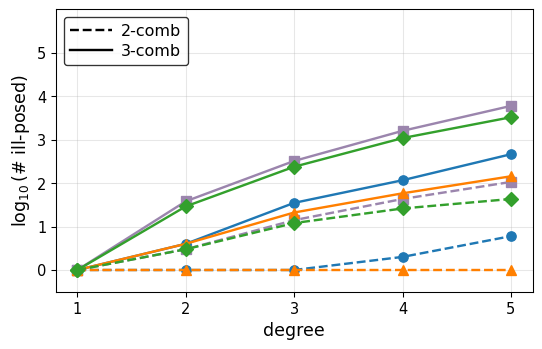

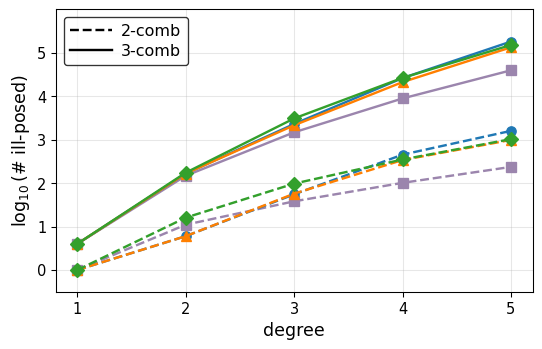

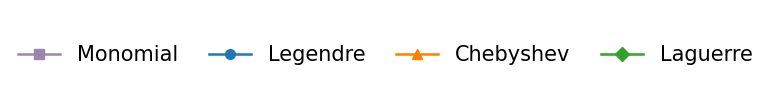

In [123]:
def safe_log10(a):
    a = np.asarray(a, dtype=float)
    return np.where(a > 0, np.log10(a), 0.0)

def _plot_two_combs_one_basis(ax, df, xcol, ycol_2, ycol_3, name):
    """
    For one basis (one df), plot both 2-comb (dashed) and 3-comb (solid).
    Legend is NOT added here (you keep a separate legend figure).
    """
    # 3-comb: same as current style (solid)
    if (xcol in df.columns) and (ycol_3 in df.columns):
        ax.plot(
            df[xcol],
            safe_log10(df[ycol_3]),
            marker=markers[name],
            linestyle='-',
            linewidth=1.8,
            markersize=7,
            color=basis_colors[name],
            label=None
        )

    # 2-comb: dashed line (same color/marker)
    if (xcol in df.columns) and (ycol_2 in df.columns):
        ax.plot(
            df[xcol],
            safe_log10(df[ycol_2]),
            marker=markers[name],
            linestyle='--',
            linewidth=1.8,
            markersize=7,
            color=basis_colors[name],
            label=None
        )

def _plot_combined(ax, dfs, xcol, ycol_2, ycol_3, ylabel=None):
    """
    Draw combined plot: 2-comb dashed + 3-comb solid for each basis.
    """
    missing = []
    for name, df in dfs.items():
        miss_cols = []
        if xcol not in df.columns:
            miss_cols.append(xcol)
        if ycol_2 not in df.columns:
            miss_cols.append(ycol_2)
        if ycol_3 not in df.columns:
            miss_cols.append(ycol_3)

        # If x is missing, nothing can be plotted
        if xcol not in df.columns:
            missing.append(f"{name} (missing: {', '.join(miss_cols)})")
            continue

        # Plot whatever exists (2 and/or 3)
        _plot_two_combs_one_basis(ax, df, xcol, ycol_2, ycol_3, name)

        # If one of the comb columns missing, record it
        if (ycol_2 not in df.columns) or (ycol_3 not in df.columns):
            missing.append(f"{name} (missing: {', '.join([c for c in [ycol_2, ycol_3] if c not in df.columns])})")

    if ylabel:
        ax.set_ylabel(ylabel, fontsize=13)

    ax.set_xlabel('degree', fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(axis='both', labelsize=11)

    # keep your original y settings
    y_ticks = [0, 1, 2, 3, 4, 5]
    ax.set_yticks(y_ticks)
    ax.set_ylim(-0.5, 6)

    if missing:
        ax.text(
            0.02, 0.02,
            "Skipped: " + "; ".join(missing),
            transform=ax.transAxes,
            fontsize=9,
            alpha=0.6,
            va='bottom'
        )

def plot_combined_23(dfs, title='', savepath=None):
    """
    One figure: 2-comb dashed + 3-comb solid.
    """
    fig, ax = plt.subplots(figsize=(5.7480, 3.7402), dpi=96)

    _plot_combined(
        ax,
        dfs,
        col_deg,
        col_2c,
        col_3c,
        ylabel=r'$\log_{10}(\#\ \mathrm{ill\text{-}posed})$'
    )

    # --- Legend for line styles only (no markers) ---
    handles_ls = [
        Line2D([0], [0], linestyle='--', linewidth=1.8, color='black', label='2-comb'),
        Line2D([0], [0], linestyle='-',  linewidth=1.8, color='black', label='3-comb')
    ]

    leg = ax.legend(
        handles=handles_ls,
        loc='upper left',
        frameon=True,
        edgecolor='black',
        fontsize=12,
        handlelength=2.6,   # legend里线段长度
        handletextpad=0.6,
        borderpad=0.4,
        labelspacing=0.3
    )
    leg.get_frame().set_linewidth(1.0)
    
    # Optional: title if you want
    # ax.set_title(title, fontsize=15)

    fig.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, dpi=96, bbox_inches='tight', pad_inches=0.02)

    plt.show()



path_lv_comb  = out_path_plots1 / "ill_comb_LV.svg"
path_crn_comb = out_path_plots1 / "ill_comb_CRN.svg"
path_legend   = out_path_plots1 / "ill_comb_legend.svg"

plot_combined_23(dfs_lv,  title="LV",  savepath=path_lv_comb)
plot_combined_23(dfs_crn, title="CRN", savepath=path_crn_comb)

plot_basis_legend(savepath=path_legend, ncol=4)

/var/folders/rl/rxtrqh0d3zz5hjzkb_g0_d3m0000gn/T/ipykernel_58387/2351714040.py:3: RuntimeWarning:

divide by zero encountered in log10



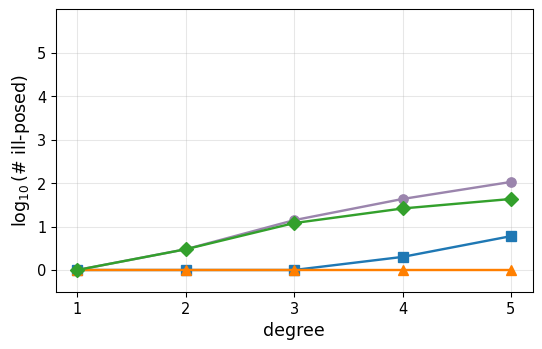

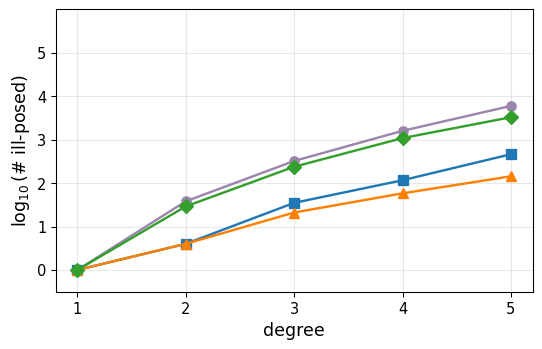

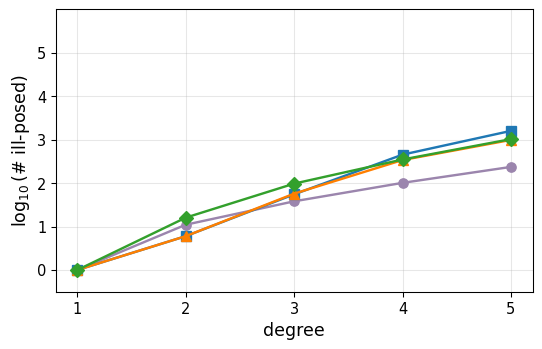

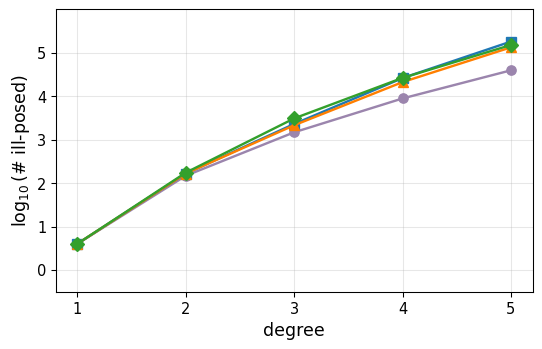

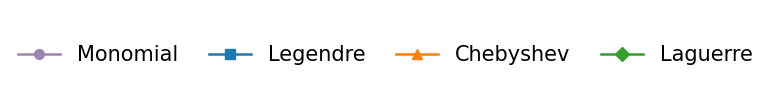

In [67]:
def safe_log10(a):
    a = np.asarray(a, dtype=float)
    return np.where(a > 0, np.log10(a), 0.0)

def _plot_one(ax, dfs, xcol, ycol, ylabel=None):
    """
    Draw a set of curves for a given basis ax (dfs is a dict: {basis_name: df})
    """
    missing = []
    for name, df in dfs.items():
        if xcol not in df.columns or ycol not in df.columns:
            missing.append(
                f"{name} (missing: {ycol if ycol not in df.columns else xcol})"
            )
            continue

        ax.plot(
            df[xcol],
            safe_log10(df[ycol]),
            marker=markers[name],
            linestyle='-',
            linewidth=1.8,
            markersize=7,
            color=basis_colors[name],
            label=name
        )

    if ylabel:
        ax.set_ylabel(ylabel, fontsize=13)

    ax.set_xlabel('degree', fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(axis='both', labelsize=11)
    y_ticks = [0, 1, 2, 3, 4, 5]
    ax.set_yticks(y_ticks)
    ax.set_ylim(-0.5, 6)

    if missing:
        ax.text(
            0.02, 0.02,
            "Skipped: " + "; ".join(missing),
            transform=ax.transAxes,
            fontsize=9,
            alpha=0.6,
            va='bottom'
        )
        
def plot_single_comb(dfs, comb='2', title='', savepath=None):
    if comb == '2':
        ycol = col_2c
        default_title = 'Ill-posed 2-combinations'
    elif comb == '3':
        ycol = col_3c
        default_title = 'Ill-posed 3-combinations'
    else:
        raise ValueError("comb must be '2' or '3'.")

    if not title:
        title = default_title

    fig, ax = plt.subplots(figsize=(5.7480, 3.7402), dpi=96)

    _plot_one(
        ax,
        dfs,
        col_deg,
        ycol,
        ylabel=r'$\log_{10}(\#\ \mathrm{ill\text{-}posed})$'
    )

    #ax.set_title(title, fontsize=15)

    # ax.legend(...)

    fig.tight_layout()
    #fig.subplots_adjust(left=0.18, right=0.98, bottom=0.18, top=0.98)

    if savepath is not None:
        fig.savefig(savepath, dpi=96, bbox_inches='tight', pad_inches=0.02)

    plt.show()


def plot_basis_legend(savepath=None, ncol=4):
    legend_order = ['Monomial', 'Legendre', 'Chebyshev', 'Laguerre']

    handles = [
        Line2D(
            [0], [0],
            color=basis_colors[name],
            marker=markers[name],
            linestyle='-',
            linewidth=1.8,
            markersize=7,
            label=name
        )
        for name in legend_order
        if name in basis_colors and name in markers
    ]

    fig, ax = plt.subplots(figsize=(7, 1.2))
    ax.axis('off')

    ax.legend(
        handles=handles,
        loc='center',
        ncol=ncol,
        frameon=False,
        fontsize=15,
        handlelength=2.0,
        columnspacing=1.5
    )

    fig.tight_layout()

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches='tight', pad_inches=0.02)

    plt.show()
    
basis_colors = {
    'Legendre' : '#1F78B4',  # Uniform
    'Chebyshev': '#FF7F00',  # Arcsine
    'Laguerre' : '#33A02C',  # Exponential
    'Monomial' : '#9B85AD',  # Monomial
}

markers = {
    'Monomial':  'o',
    'Legendre':  's',
    'Chebyshev': '^',
    'Laguerre':  'D',
}

col_deg = 'degree'
col_2c  = '# ill-posed 2comb'
col_3c  = '# ill-posed 3comb'

path_lv_2 = out_path_plots1 / "ill_2comb_LV.svg"
path_lv_3 = out_path_plots1 / "ill_3comb_LV.svg"
path_crn_2 = out_path_plots1 / "ill_2comb_CRN.svg"
path_crn_3 = out_path_plots1 / "ill_3comb_CRN.svg"
path_legend = out_path_plots1 / "ill_comb_legend.svg"

plot_single_comb(dfs_lv,  comb='2', title=None,  savepath=path_lv_2)
plot_single_comb(dfs_lv,  comb='3', title=None,  savepath=path_lv_3)
plot_single_comb(dfs_crn, comb='2', title=None, savepath=path_crn_2)
plot_single_comb(dfs_crn, comb='3', title=None, savepath=path_crn_3)

# legend
plot_basis_legend(savepath=path_legend, ncol=4)

Plots 2: Condition number of [wrong | missing] terms, and the plot has four subplots. Each of them has four lines representing basis (Monomial, Legendre, Chebyshev and Laguerre), x axis representing degree, y axis representing condition number

Chemical Reaction Network

Monomial Basis

In [1585]:
# Create function libarary and generate corresponding values for each degree
degree_range = [2]
candidate_libs_crn = {}
recover_crn_monomial,cond_crn_monomial, Missing_crn_monomial, Wrong_crn_monomial, discovered_terms_monomial, original_terms_monomial= {}, {}, {}, {}, {}, {}
threshold_vals = {
    '2': 8e-2,
    '3': 1e-1,
    '4': 1e-2,
    '5': 1e-2
}
# original model
crn_model = Comparison.Terms_Identification_original(CRN_model)
variable_mapping,all_xi_terms = crn_model._parse_model()
for poly_degree in degree_range:
    poly_feature_ob = PolyFeatureMatrix(poly_degree)
    candidate_lib_full = poly_feature_ob.fit_transform(data_states_crn)
    # Dropping 1 from the candidate library since we use fit_with_intercept flag instead of using constants directly
    # in the candidate library
    candidate_lib_full = candidate_lib_full.drop(["1"], axis=1)
    candidate_libs_crn[poly_degree] = candidate_lib_full

    # DAE_finder
    #recover = Comparison.Recover_Model_sindy(candidate_lib_full,data_derivatives_beer,threshold=1e-5)
    # SINDy 

    threshold = threshold_vals[str(poly_degree)]
    recover_monomial  = Recover_Model_sindy(data_crn,differential_order=2,poly_degree=poly_degree,threshold=threshold,
                                            method='Monomial', L=min_crn,U=max_crn,denormalize=False)
    recovered_model_monomial = recover_monomial.model_expression
    recover_crn_monomial[poly_degree] = recover_monomial

    Analyzer_crn_monomial = Comparison.Terms_Analysis(CRN_model,recovered_model_monomial,variable_mapping,candidate_lib_full)
    dis_terms,orig_terms = Analyzer_crn_monomial.discovered_terms,Analyzer_crn_monomial.original_terms
    discovered_terms_monomial[poly_degree],original_terms_monomial[poly_degree] = dis_terms,orig_terms
    #raw_disc,raw_orig = Analyzer_Beer.raw_terms_disc,Analyzer_Beer.raw_terms_orig
    condition_number, wrong, missing = Analyzer_crn_monomial.con, Analyzer_crn_monomial.wrong_terms, Analyzer_crn_monomial.missing_terms
    cond_crn_monomial[poly_degree],Wrong_crn_monomial[poly_degree], Missing_crn_monomial[poly_degree] = condition_number, wrong, missing

features: ['x1', 'x2', 'x3', 'x4'] n_vars= 4


In [1586]:
discovered_terms_monomial[2]['dx4/dt']

['x1 x2', 'x1 x3', 'x1 x4', 'x2 x3', 'x3', 'x3 x4', 'x3^2']

In [1587]:
recover_crn_monomial[2].model_expression.iloc[3,1]

'0.106 x3 + 0.367 x1 x2 + 0.033 x1 x3 + 0.309 x1 x4 + 0.155 x2 x3 + 0.163 x3^2 + 0.175 x3 x4'

In [1588]:
cond_crn_monomial[2]

{'dx1/dt': {'Condition Number': 1.2661695853532478e+17},
 'dx2/dt': {'Condition Number': 2.2344222236397192e+18},
 'dx3/dt': {'Condition Number': 2.2344222236397192e+18},
 'dx4/dt': {'Condition Number': 2.5184497059491914e+17}}

In [1548]:
Missing_crn_monomial[2]['dx4/dt']

set()

In [1050]:
Wrong_crn_monomial[2]['dx4/dt']

{'x1 x2', 'x2 x3', 'x3 x4'}

Legendre Basis

In [10]:
# Create function libarary and generate corresponding values for each degree
degree_range = [2,3,4,5]
candidate_libs_crn = {}
recover_crn_legendre,cond_crn_legendre, Missing_crn_legendre, Wrong_crn_legendre, discovered_terms_legendre, original_terms_legendre= {}, {}, {}, {}, {}, {}
threshold_vals = {
    '2': 1e-2,
    '3': 1e-1,
    '4': 1e-2,
    '5': 1e-2
}
after_threshold = 0.9
# original model
crn_model = Comparison.Terms_Identification_original(CRN_model)
variable_mapping,all_xi_terms = crn_model._parse_model()
for poly_degree in degree_range:
    poly_feature_ob = PolyFeatureMatrix(poly_degree)
    candidate_lib_full = poly_feature_ob.fit_transform(data_states_crn)
    # Dropping 1 from the candidate library since we use fit_with_intercept flag instead of using constants directly
    # in the candidate library
    candidate_lib_full = candidate_lib_full.drop(["1"], axis=1)
    candidate_libs_crn[poly_degree] = candidate_lib_full

    # DAE_finder
    #recover = Comparison.Recover_Model_sindy(candidate_lib_full,data_derivatives_beer,threshold=1e-5)
    # SINDy 

    threshold = threshold_vals[str(poly_degree)]
    recover_legendre  = Recover_Model_sindy(data_crn_normalized,differential_order=2,poly_degree=poly_degree,threshold=threshold,
                                            method='Legendre',L=min_crn,U=max_crn,after_threshold=after_threshold)
    recovered_model_legendre = recover_legendre.model_expression
    recover_crn_legendre[poly_degree] = recover_legendre

    Analyzer_crn_legendre = Comparison.Terms_Analysis(CRN_model,recovered_model_legendre,variable_mapping,candidate_lib_full)
    dis_terms,orig_terms = Analyzer_crn_legendre.discovered_terms,Analyzer_crn_legendre.original_terms
    discovered_terms_legendre[poly_degree],original_terms_legendre[poly_degree] = dis_terms,orig_terms
    #raw_disc,raw_orig = Analyzer_Beer.raw_terms_disc,Analyzer_Beer.raw_terms_orig
    condition_number, wrong, missing = Analyzer_crn_legendre.con, Analyzer_crn_legendre.wrong_terms, Analyzer_crn_legendre.missing_terms
    cond_crn_legendre[poly_degree],Wrong_crn_legendre[poly_degree], Missing_crn_legendre[poly_degree] = condition_number, wrong, missing

features: ['x1', 'x2', 'x3', 'x4'] n_vars= 4
len(eq_list)= 4
Transformation matrices built:
A (diagonal): [0.8006494642237703, 1.2691481955080113, 1.2691481955080122, 0.5733013227100373]
b (vector): [-1.0016236605594255, -2.7955079910431553, -1.0119365954808803, -1.0]
A^(-1) (diagonal): [1.2489860353175908, 0.7879300490985788, 0.7879300490985782, 1.7442834341859301]
[AFTER-THRESH] filtered 6 term(s) in dx1/dt with threshold=0.9
[AFTER-THRESH] filtered 7 term(s) in dx2/dt with threshold=0.9
[AFTER-THRESH] filtered 7 term(s) in dx3/dt with threshold=0.9
[AFTER-THRESH] filtered 12 term(s) in dx4/dt with threshold=0.9
features: ['x1', 'x2', 'x3', 'x4'] n_vars= 4
len(eq_list)= 4
Transformation matrices built:
A (diagonal): [0.8006494642237703, 1.2691481955080113, 1.2691481955080122, 0.5733013227100373]
b (vector): [-1.0016236605594255, -2.7955079910431553, -1.0119365954808803, -1.0]
A^(-1) (diagonal): [1.2489860353175908, 0.7879300490985788, 0.7879300490985782, 1.7442834341859301]
[AFTER-TH

In [11]:
discovered_terms_legendre[2]['dx4/dt']

['x1', 'x3']

Chebyshev Basis

In [12]:
# Create function libarary and generate corresponding values for each degree
degree_range = [2,3,4,5]
candidate_libs_crn = {}
recover_crn_chebyshev,cond_crn_chebyshev, Missing_crn_chebyshev, Wrong_crn_chebyshev, discovered_terms_chebyshev, original_terms_chebyshev= {}, {}, {}, {}, {}, {}
threshold_vals = {
    '2': 1e-2,
    '3': 1e-1,
    '4': 1e-1,
    '5': 1e-2
}
after_threshold = 0.9
# original model
crn_model = Comparison.Terms_Identification_original(CRN_model)
variable_mapping,all_xi_terms = crn_model._parse_model()
for poly_degree in degree_range:
    poly_feature_ob = PolyFeatureMatrix(poly_degree)
    candidate_lib_full = poly_feature_ob.fit_transform(data_states_crn)
    # Dropping 1 from the candidate library since we use fit_with_intercept flag instead of using constants directly
    # in the candidate library
    candidate_lib_full = candidate_lib_full.drop(["1"], axis=1)
    candidate_libs_crn[poly_degree] = candidate_lib_full

    # DAE_finder
    #recover = Comparison.Recover_Model_sindy(candidate_lib_full,data_derivatives_beer,threshold=1e-5)
    # SINDy 

    threshold = threshold_vals[str(poly_degree)]
    recover_chebyshev  = Recover_Model_sindy(data_crn_normalized,differential_order=2,poly_degree=poly_degree,threshold=threshold,
                                             method='Chebyshev',L=min_crn,U=max_crn,after_threshold=after_threshold)
    recovered_model_chebyshev = recover_chebyshev.model_expression
    recover_crn_chebyshev[poly_degree] = recover_chebyshev

    Analyzer_crn_chebyshev = Comparison.Terms_Analysis(CRN_model,recovered_model_chebyshev,variable_mapping,candidate_lib_full)
    dis_terms,orig_terms = Analyzer_crn_chebyshev.discovered_terms,Analyzer_crn_chebyshev.original_terms
    discovered_terms_chebyshev[poly_degree],original_terms_chebyshev[poly_degree] = dis_terms,orig_terms
    #raw_disc,raw_orig = Analyzer_Beer.raw_terms_disc,Analyzer_Beer.raw_terms_orig
    condition_number, wrong, missing = Analyzer_crn_chebyshev.con, Analyzer_crn_chebyshev.wrong_terms, Analyzer_crn_chebyshev.missing_terms
    cond_crn_chebyshev[poly_degree],Wrong_crn_chebyshev[poly_degree], Missing_crn_chebyshev[poly_degree] = condition_number, wrong, missing

features: ['x1', 'x2', 'x3', 'x4'] n_vars= 4
len(eq_list)= 4
Transformation matrices built:
A (diagonal): [0.8006494642237703, 1.2691481955080113, 1.2691481955080122, 0.5733013227100373]
b (vector): [-1.0016236605594255, -2.7955079910431553, -1.0119365954808803, -1.0]
A^(-1) (diagonal): [1.2489860353175908, 0.7879300490985788, 0.7879300490985782, 1.7442834341859301]
[AFTER-THRESH] filtered 6 term(s) in dx1/dt with threshold=0.9
[AFTER-THRESH] filtered 6 term(s) in dx2/dt with threshold=0.9
[AFTER-THRESH] filtered 6 term(s) in dx3/dt with threshold=0.9
[AFTER-THRESH] filtered 12 term(s) in dx4/dt with threshold=0.9
features: ['x1', 'x2', 'x3', 'x4'] n_vars= 4
len(eq_list)= 4
Transformation matrices built:
A (diagonal): [0.8006494642237703, 1.2691481955080113, 1.2691481955080122, 0.5733013227100373]
b (vector): [-1.0016236605594255, -2.7955079910431553, -1.0119365954808803, -1.0]
A^(-1) (diagonal): [1.2489860353175908, 0.7879300490985788, 0.7879300490985782, 1.7442834341859301]
[AFTER-TH

In [13]:
discovered_terms_chebyshev[2]['dx4/dt']

['x1', 'x3']

Laguerre Basis

In [14]:
# Create function libarary and generate corresponding values for each degree
degree_range = [2,3,4,5]
candidate_libs_crn = {}
recover_crn_laguerre,cond_crn_laguerre, Missing_crn_laguerre, Wrong_crn_laguerre, discovered_terms_laguerre, original_terms_laguerre= {}, {}, {}, {}, {}, {}
threshold_vals = {
    '2': 1e-1,
    '3': 1e-1,
    '4': 1e-1,
    '5': 1e-1
}
after_threshold = 0.9
# original model
crn_model = Comparison.Terms_Identification_original(CRN_model)
variable_mapping,all_xi_terms = crn_model._parse_model()
for poly_degree in degree_range:
    poly_feature_ob = PolyFeatureMatrix(poly_degree)
    candidate_lib_full = poly_feature_ob.fit_transform(data_states_crn)
    # Dropping 1 from the candidate library since we use fit_with_intercept flag instead of using constants directly
    # in the candidate library
    candidate_lib_full = candidate_lib_full.drop(["1"], axis=1)
    candidate_libs_crn[poly_degree] = candidate_lib_full

    # DAE_finder
    #recover = Comparison.Recover_Model_sindy(candidate_lib_full,data_derivatives_beer,threshold=1e-5)
    # SINDy 

    threshold = threshold_vals[str(poly_degree)]
    recover_laguerre  = Recover_Model_sindy(data_crn,differential_order=2,poly_degree=poly_degree,threshold=threshold,
                                             method='Laguerre',L=min_crn,U=max_crn,after_threshold=after_threshold)
    recovered_model_laguerre = recover_laguerre.model_expression
    recover_crn_laguerre[poly_degree] = recover_laguerre

    Analyzer_crn_laguerre = Comparison.Terms_Analysis(CRN_model,recovered_model_laguerre,variable_mapping,candidate_lib_full)
    dis_terms,orig_terms = Analyzer_crn_laguerre.discovered_terms,Analyzer_crn_laguerre.original_terms
    discovered_terms_laguerre[poly_degree],original_terms_laguerre[poly_degree] = dis_terms,orig_terms
    #raw_disc,raw_orig = Analyzer_Beer.raw_terms_disc,Analyzer_Beer.raw_terms_orig
    condition_number, wrong, missing = Analyzer_crn_laguerre.con, Analyzer_crn_laguerre.wrong_terms, Analyzer_crn_laguerre.missing_terms
    cond_crn_laguerre[poly_degree],Wrong_crn_laguerre[poly_degree], Missing_crn_laguerre[poly_degree] = condition_number, wrong, missing

features: ['x1', 'x2', 'x3', 'x4'] n_vars= 4
len(eq_list)= 4
Transformation matrices built:
A (diagonal): [0.8006494642237703, 1.2691481955080113, 1.2691481955080122, 0.5733013227100373]
b (vector): [-1.0016236605594255, -2.7955079910431553, -1.0119365954808803, -1.0]
A^(-1) (diagonal): [1.2489860353175908, 0.7879300490985788, 0.7879300490985782, 1.7442834341859301]
[AFTER-THRESH] filtered 5 term(s) in dx1/dt with threshold=0.9
[AFTER-THRESH] filtered 8 term(s) in dx2/dt with threshold=0.9
[AFTER-THRESH] filtered 8 term(s) in dx3/dt with threshold=0.9
[AFTER-THRESH] filtered 7 term(s) in dx4/dt with threshold=0.9
features: ['x1', 'x2', 'x3', 'x4'] n_vars= 4
len(eq_list)= 4
Transformation matrices built:
A (diagonal): [0.8006494642237703, 1.2691481955080113, 1.2691481955080122, 0.5733013227100373]
b (vector): [-1.0016236605594255, -2.7955079910431553, -1.0119365954808803, -1.0]
A^(-1) (diagonal): [1.2489860353175908, 0.7879300490985788, 0.7879300490985782, 1.7442834341859301]
[AFTER-THR

In [15]:
discovered_terms_laguerre[2]['dx4/dt']

['x1', 'x2', 'x3']

Lotka-Volterra Model

Monomial Basis

3e-2, 3e-3, 2.7e-2

In [766]:
# Create function libarary and generate corresponding values for each degree
degree_range = [3]
candidate_libs_lv = {}
recover_lv_monomial,cond_lv_monomial, Missing_lv_monomial, Wrong_lv_monomial, discovered_terms_lv_monomial, original_terms_lv_monomial= {}, {}, {}, {}, {}, {}
threshold_vals = {
    '2': 1e-1,
    '3': 1e-2,
    '4': 1e-2,
    '5': 1e-2
}
after_threshold = 0.01
# original model
lv_model = Comparison.Terms_Identification_original(LV_model)
variable_mapping,all_xi_terms = lv_model._parse_model()
for poly_degree in degree_range:
    poly_feature_ob = PolyFeatureMatrix(poly_degree)
    candidate_lib_full = poly_feature_ob.fit_transform(data_states_lv)
    # Dropping 1 from the candidate library since we use fit_with_intercept flag instead of using constants directly
    # in the candidate library
    candidate_lib_full = candidate_lib_full.drop(["1"], axis=1)
    candidate_libs_lv[poly_degree] = candidate_lib_full

    # DAE_finder
    #recover = Comparison.Recover_Model_sindy(candidate_lib_full,data_derivatives_beer,threshold=1e-5)
    # SINDy 

    threshold = threshold_vals[str(poly_degree)]
    recover_monomial  = Recover_Model_sindy(data_lv,differential_order=2,poly_degree=poly_degree,threshold=2.7e-2,alpha=0.1,
                                            method='Monomial',L=min_lv,U=max_lv,denormalize=False,after_threshold=None)
    recovered_model_monomial = recover_monomial.model_expression
    recover_lv_monomial[poly_degree] = recover_monomial

    Analyzer_lv_monomial = Comparison.Terms_Analysis(LV_model,recovered_model_monomial, variable_mapping,candidate_lib_full)
    dis_terms,orig_terms = Analyzer_lv_monomial.discovered_terms, Analyzer_lv_monomial.original_terms
    discovered_terms_lv_monomial[poly_degree], original_terms_lv_monomial[poly_degree] = dis_terms, orig_terms
    #raw_disc,raw_orig = Analyzer_Beer.raw_terms_disc,Analyzer_Beer.raw_terms_orig
    condition_number, wrong, missing = Analyzer_lv_monomial.con, Analyzer_lv_monomial.wrong_terms, Analyzer_lv_monomial.missing_terms
    cond_lv_monomial[poly_degree], Wrong_lv_monomial[poly_degree], Missing_lv_monomial[poly_degree] = condition_number, wrong, missing

features: ['x1', 'x2', 'x3'] n_vars= 3


/Users/yuxiangfeng/Desktop/SINDy/3.Dependence/illposed_env/lib/python3.12/site-packages/pysindy/optimizers/stlsq.py:201: UserWarning:

Sparsity parameter is too big (0.027) and eliminated all coefficients

/Users/yuxiangfeng/Desktop/SINDy/3.Dependence/illposed_env/lib/python3.12/site-packages/pysindy/optimizers/stlsq.py:201: UserWarning:

Sparsity parameter is too big (0.027) and eliminated all coefficients



In [767]:
recover_lv_monomial[3].model_expression.iloc[2,1]

'-0.098 x3 + 6.136 x1^2 - 2.020 x1^3 - 1.441 x1^2 x3 + 0.109 x1 x3^2'

In [768]:
cond_lv_monomial[3]

{'dx1/dt': {'Condition Number': 1305664.072685372},
 'dx2/dt': {'Condition Number': 2.2988717204662157},
 'dx3/dt': {'Condition Number': 12312.37300109916}}

In [769]:
Missing_lv_monomial[3]['dx3/dt']

{'x1 x3'}

In [770]:
Wrong_lv_monomial[3]['dx3/dt']

{'x1 x3^2', 'x1^2', 'x1^2 x3', 'x1^3'}

Legendre Basis

In [18]:
# Create function libarary and generate corresponding values for each degree
degree_range = [2,3,4,5]
candidate_libs_lv = {}
recover_lv_legendre,cond_lv_legendre, Missing_lv_legendre, Wrong_lv_legendre, discovered_terms_lv_legendre, original_terms_lv_legendre= {}, {}, {}, {}, {}, {}
threshold_vals = {
    '2': 1e-2,
    '3': 1e-2,
    '4': 1e-2,
    '5': 1e-2
}
after_threshold = 0.01
# original model
lv_model = Comparison.Terms_Identification_original(LV_model)
variable_mapping,all_xi_terms = lv_model._parse_model()
for poly_degree in degree_range:
    poly_feature_ob = PolyFeatureMatrix(poly_degree)
    candidate_lib_full = poly_feature_ob.fit_transform(data_states_lv)
    # Dropping 1 from the candidate library since we use fit_with_intercept flag instead of using constants directly
    # in the candidate library
    candidate_lib_full = candidate_lib_full.drop(["1"], axis=1)
    candidate_libs_lv[poly_degree] = candidate_lib_full

    # DAE_finder
    #recover = Comparison.Recover_Model_sindy(candidate_lib_full,data_derivatives_beer,threshold=1e-5)
    # SINDy 

    threshold = threshold_vals[str(poly_degree)]
    recover_legendre  = Recover_Model_sindy(data_lv_normalized,differential_order=2,poly_degree=poly_degree,threshold=1e-4,
                                            method='Legendre',L=min_lv,U=max_lv,after_threshold=after_threshold)
    recovered_model_legendre = recover_legendre.model_expression
    recover_lv_legendre[poly_degree] = recover_legendre

    Analyzer_lv_legendre = Comparison.Terms_Analysis(LV_model,recovered_model_legendre, variable_mapping,candidate_lib_full)
    dis_terms,orig_terms = Analyzer_lv_legendre.discovered_terms, Analyzer_lv_legendre.original_terms
    discovered_terms_lv_legendre[poly_degree], original_terms_lv_legendre[poly_degree] = dis_terms, orig_terms
    #raw_disc,raw_orig = Analyzer_Beer.raw_terms_disc,Analyzer_Beer.raw_terms_orig
    condition_number, wrong, missing = Analyzer_lv_legendre.con, Analyzer_lv_legendre.wrong_terms, Analyzer_lv_legendre.missing_terms
    cond_lv_legendre[poly_degree], Wrong_lv_legendre[poly_degree], Missing_lv_legendre[poly_degree] = condition_number, wrong, missing

features: ['x1', 'x2'] n_vars= 2
len(eq_list)= 2
Transformation matrices built:
A (diagonal): [0.028653295128939823, 0.036101083032490974]
b (vector): [-1.2177650429799425, -1.144404332129964]
A^(-1) (diagonal): [34.900000000000006, 27.7]
[AFTER-THRESH] filtered 2 term(s) in dx1/dt with threshold=0.01
[AFTER-THRESH] filtered 1 term(s) in dx2/dt with threshold=0.01
features: ['x1', 'x2'] n_vars= 2
len(eq_list)= 2
Transformation matrices built:
A (diagonal): [0.028653295128939823, 0.036101083032490974]
b (vector): [-1.2177650429799425, -1.144404332129964]
A^(-1) (diagonal): [34.900000000000006, 27.7]
[AFTER-THRESH] filtered 4 term(s) in dx1/dt with threshold=0.01
[AFTER-THRESH] filtered 4 term(s) in dx2/dt with threshold=0.01
features: ['x1', 'x2'] n_vars= 2
len(eq_list)= 2
Transformation matrices built:
A (diagonal): [0.028653295128939823, 0.036101083032490974]
b (vector): [-1.2177650429799425, -1.144404332129964]
A^(-1) (diagonal): [34.900000000000006, 27.7]
[AFTER-THRESH] filtered 9 t

In [19]:
discovered_terms_lv_legendre

{2: {'dx1/dt': ['x1', 'x1 x2', 'x2'], 'dx2/dt': ['x1', 'x1 x2', 'x2', 'x2^2']},
 3: {'dx1/dt': ['x1', 'x1 x2', 'x1^2', 'x2', 'x2^2'],
  'dx2/dt': ['x1', 'x1 x2', 'x1^2', 'x2', 'x2^2']},
 4: {'dx1/dt': ['x1', 'x1 x2', 'x1^2', 'x2', 'x2^2'],
  'dx2/dt': ['x1', 'x1 x2', 'x1^2', 'x2', 'x2^2']},
 5: {'dx1/dt': ['x1',
   'x1 x2',
   'x1 x2^2',
   'x1 x2^3',
   'x1^2',
   'x1^2 x2',
   'x1^2 x2^2',
   'x1^2 x2^3',
   'x1^3',
   'x1^3 x2',
   'x1^4',
   'x2',
   'x2^2',
   'x2^3',
   'x2^4',
   'x2^5'],
  'dx2/dt': ['x1',
   'x1 x2',
   'x1 x2^2',
   'x1 x2^3',
   'x1^2',
   'x1^2 x2',
   'x1^2 x2^2',
   'x1^3',
   'x1^3 x2',
   'x1^4',
   'x2',
   'x2^2',
   'x2^3',
   'x2^4']}}

Chebyshev Basis

In [20]:
# Create function libarary and generate corresponding values for each degree
degree_range = [2,3,4,5]
candidate_libs_lv = {}
recover_lv_chebyshev,cond_lv_chebyshev, Missing_lv_chebyshev, Wrong_lv_chebyshev, discovered_terms_lv_chebyshev, original_terms_lv_chebyshev= {}, {}, {}, {}, {}, {}
threshold_vals = {
    '2': 1e-2,
    '3': 1e-2,
    '4': 1e-2,
    '5': 1e-2
}
after_threshold = 0.01
# original model
lv_model = Comparison.Terms_Identification_original(LV_model)
variable_mapping,all_xi_terms = lv_model._parse_model()
for poly_degree in degree_range:
    poly_feature_ob = PolyFeatureMatrix(poly_degree)
    candidate_lib_full = poly_feature_ob.fit_transform(data_states_lv)
    # Dropping 1 from the candidate library since we use fit_with_intercept flag instead of using constants directly
    # in the candidate library
    candidate_lib_full = candidate_lib_full.drop(["1"], axis=1)
    candidate_libs_lv[poly_degree] = candidate_lib_full

    # DAE_finder
    #recover = Comparison.Recover_Model_sindy(candidate_lib_full,data_derivatives_beer,threshold=1e-5)
    # SINDy 

    threshold = threshold_vals[str(poly_degree)]
    recover_chebyshev  = Recover_Model_sindy(data_lv_normalized,differential_order=2,poly_degree=poly_degree,threshold=1e-4,
                                            method='Chebyshev',L=min_lv,U=max_lv,after_threshold=after_threshold)
    recovered_model_chebyshev = recover_chebyshev.model_expression
    recover_lv_chebyshev[poly_degree] = recover_chebyshev

    Analyzer_lv_chebyshev = Comparison.Terms_Analysis(LV_model,recovered_model_chebyshev, variable_mapping,candidate_lib_full)
    dis_terms,orig_terms = Analyzer_lv_chebyshev.discovered_terms, Analyzer_lv_chebyshev.original_terms
    discovered_terms_lv_chebyshev[poly_degree], original_terms_lv_chebyshev[poly_degree] = dis_terms, orig_terms
    #raw_disc,raw_orig = Analyzer_Beer.raw_terms_disc,Analyzer_Beer.raw_terms_orig
    condition_number, wrong, missing = Analyzer_lv_chebyshev.con, Analyzer_lv_chebyshev.wrong_terms, Analyzer_lv_chebyshev.missing_terms
    cond_lv_chebyshev[poly_degree], Wrong_lv_chebyshev[poly_degree], Missing_lv_chebyshev[poly_degree] = condition_number, wrong, missing

features: ['x1', 'x2'] n_vars= 2
len(eq_list)= 2
Transformation matrices built:
A (diagonal): [0.028653295128939823, 0.036101083032490974]
b (vector): [-1.2177650429799425, -1.144404332129964]
A^(-1) (diagonal): [34.900000000000006, 27.7]
[AFTER-THRESH] filtered 2 term(s) in dx1/dt with threshold=0.01
[AFTER-THRESH] filtered 1 term(s) in dx2/dt with threshold=0.01
features: ['x1', 'x2'] n_vars= 2
len(eq_list)= 2
Transformation matrices built:
A (diagonal): [0.028653295128939823, 0.036101083032490974]
b (vector): [-1.2177650429799425, -1.144404332129964]
A^(-1) (diagonal): [34.900000000000006, 27.7]
[AFTER-THRESH] filtered 4 term(s) in dx1/dt with threshold=0.01
[AFTER-THRESH] filtered 4 term(s) in dx2/dt with threshold=0.01
features: ['x1', 'x2'] n_vars= 2
len(eq_list)= 2
Transformation matrices built:
A (diagonal): [0.028653295128939823, 0.036101083032490974]
b (vector): [-1.2177650429799425, -1.144404332129964]
A^(-1) (diagonal): [34.900000000000006, 27.7]
[AFTER-THRESH] filtered 9 t

In [21]:
discovered_terms_lv_legendre

{2: {'dx1/dt': ['x1', 'x1 x2', 'x2'], 'dx2/dt': ['x1', 'x1 x2', 'x2', 'x2^2']},
 3: {'dx1/dt': ['x1', 'x1 x2', 'x1^2', 'x2', 'x2^2'],
  'dx2/dt': ['x1', 'x1 x2', 'x1^2', 'x2', 'x2^2']},
 4: {'dx1/dt': ['x1', 'x1 x2', 'x1^2', 'x2', 'x2^2'],
  'dx2/dt': ['x1', 'x1 x2', 'x1^2', 'x2', 'x2^2']},
 5: {'dx1/dt': ['x1',
   'x1 x2',
   'x1 x2^2',
   'x1 x2^3',
   'x1^2',
   'x1^2 x2',
   'x1^2 x2^2',
   'x1^2 x2^3',
   'x1^3',
   'x1^3 x2',
   'x1^4',
   'x2',
   'x2^2',
   'x2^3',
   'x2^4',
   'x2^5'],
  'dx2/dt': ['x1',
   'x1 x2',
   'x1 x2^2',
   'x1 x2^3',
   'x1^2',
   'x1^2 x2',
   'x1^2 x2^2',
   'x1^3',
   'x1^3 x2',
   'x1^4',
   'x2',
   'x2^2',
   'x2^3',
   'x2^4']}}

Laguerre Basis

In [22]:
# Create function libarary and generate corresponding values for each degree
degree_range = [2,3,4,5]
candidate_libs_lv = {}
recover_lv_laguerre,cond_lv_laguerre, Missing_lv_laguerre, Wrong_lv_laguerre, discovered_terms_lv_laguerre, original_terms_lv_laguerre= {}, {}, {}, {}, {}, {}
threshold_vals = {
    '2': 1e-2,
    '3': 1e-2,
    '4': 1e-2,
    '5': 1e-2
}
after_threshold = 0.01
# original model
lv_model = Comparison.Terms_Identification_original(LV_model)
variable_mapping,all_xi_terms = lv_model._parse_model()
for poly_degree in degree_range:
    poly_feature_ob = PolyFeatureMatrix(poly_degree)
    candidate_lib_full = poly_feature_ob.fit_transform(data_states_lv)
    # Dropping 1 from the candidate library since we use fit_with_intercept flag instead of using constants directly
    # in the candidate library
    candidate_lib_full = candidate_lib_full.drop(["1"], axis=1)
    candidate_libs_lv[poly_degree] = candidate_lib_full

    # DAE_finder
    #recover = Comparison.Recover_Model_sindy(candidate_lib_full,data_derivatives_beer,threshold=1e-5)
    # SINDy 

    threshold = threshold_vals[str(poly_degree)]
    recover_laguerre  = Recover_Model_sindy(data_lv,differential_order=2,poly_degree=poly_degree,threshold=1e-4,method='Laguerre',
                                            L=min_lv,U=max_lv,after_threshold=after_threshold)
    recovered_model_laguerre = recover_laguerre.model_expression
    recover_lv_laguerre[poly_degree] = recover_laguerre

    Analyzer_lv_laguerre = Comparison.Terms_Analysis(LV_model,recovered_model_laguerre, variable_mapping,candidate_lib_full)
    dis_terms,orig_terms = Analyzer_lv_laguerre.discovered_terms, Analyzer_lv_laguerre.original_terms
    discovered_terms_lv_laguerre[poly_degree], original_terms_lv_laguerre[poly_degree] = dis_terms, orig_terms
    #raw_disc,raw_orig = Analyzer_Beer.raw_terms_disc,Analyzer_Beer.raw_terms_orig
    condition_number, wrong, missing = Analyzer_lv_laguerre.con, Analyzer_lv_laguerre.wrong_terms, Analyzer_lv_laguerre.missing_terms
    cond_lv_laguerre[poly_degree], Wrong_lv_laguerre[poly_degree], Missing_lv_laguerre[poly_degree] = condition_number, wrong, missing

features: ['x1', 'x2'] n_vars= 2
len(eq_list)= 2
Transformation matrices built:
A (diagonal): [0.028653295128939823, 0.036101083032490974]
b (vector): [-1.2177650429799425, -1.144404332129964]
A^(-1) (diagonal): [34.900000000000006, 27.7]
[AFTER-THRESH] filtered 3 term(s) in dx1/dt with threshold=0.01
[AFTER-THRESH] filtered 3 term(s) in dx2/dt with threshold=0.01
features: ['x1', 'x2'] n_vars= 2
len(eq_list)= 2
Transformation matrices built:
A (diagonal): [0.028653295128939823, 0.036101083032490974]
b (vector): [-1.2177650429799425, -1.144404332129964]
A^(-1) (diagonal): [34.900000000000006, 27.7]
[AFTER-THRESH] filtered 6 term(s) in dx1/dt with threshold=0.01
[AFTER-THRESH] filtered 6 term(s) in dx2/dt with threshold=0.01
features: ['x1', 'x2'] n_vars= 2
len(eq_list)= 2
Transformation matrices built:
A (diagonal): [0.028653295128939823, 0.036101083032490974]
b (vector): [-1.2177650429799425, -1.144404332129964]
A^(-1) (diagonal): [34.900000000000006, 27.7]
[AFTER-THRESH] filtered 7 t

In [23]:
discovered_terms_lv_laguerre

{2: {'dx1/dt': ['x1', 'x2'], 'dx2/dt': ['x1', 'x2']},
 3: {'dx1/dt': ['x1', 'x2'], 'dx2/dt': ['x1', 'x2']},
 4: {'dx1/dt': ['x1', 'x2'], 'dx2/dt': ['x1', 'x2']},
 5: {'dx1/dt': ['x1', 'x1 x2', 'x1^2', 'x2', 'x2^2'],
  'dx2/dt': ['x1', 'x2', 'x2^2']}}